# NB-10 · Decision Trees — S3×S6 Branching

**Análise Prescritiva — Camada de Decisão**

| Campo | Detalhe |
|---|---|
| **Notebook** | NB-10 · Decision Trees (S3×S6) |
| **Autor** | Matheus Mendes |
| **Data** | 27/julho/2026 |
| **Versão** | 1.0 |
| **Dependências** | numpy, pandas, plotly, matplotlib, graphviz, json |

---

## Sumário

Este notebook constrói o **mapa de árvores de decisão** que conecta o cenário regulatório
(S3) ao protocolo defensivo (S6), com overlays das outras camadas (S1, S2, S4, S5).

1. **S3 = Cenário regulatório** (4 estados: R0 base / R1 cota / R2 contingência / R3 rollback)
2. **S6 = Protocolo defensivo** (3 níveis: D0 inativo / D1 parcial / D2 completo)
3. **Árvores**: 12 árvores (4×3 combinações) com regras condicionais
4. **Overlays**: S1 (FX), S2 (supply chain HHI), S4 (competition), S5 (composite index)
5. **Thresholds**: gatilhos quantitativos para mudança de ramo
6. **Decision matrix final**: tabela de ação por combinação

---

## Resultados-chave (CLIFF NOTES)

| Métrica | Valor | Interpretação |
|---|---|---|
| Combinações S3×S6 | **12 árvores** | 4 cenários regulatórios × 3 protocolos defensivos |
| Branches por árvore | **2-4 folhas** | Cada árvore termina em ação concreta |
| Overlays por árvore | **4 camadas** | S1, S2, S4, S5 modulados em cada folha |
| Trigger thresholds | **8 gatilhos** | PTAX vol, HHI, composite index, etc. |
| Regra dominante | **R1∧D1 = hedge 60-80%** | Cenário mais provável (P=42%) |
| Regra extrema | **R3∧D2 = abort** | Rollback + defensivo total = exit strategy |
| Acurácia esperada | **87%** | Backtest NB-08: 13% falsos positivos |

---

## Estrutura do Notebook

1. Definição da matriz S3×S6 (12 combinações)
2. Regras condicionais por branch (lógica booleana)
3. Overlays de S1, S2, S4, S5 em cada folha
4. Construção de 12 árvores de decisão (visualização Graphviz)
5. Trigger thresholds (8 gatilhos quantitativos)
6. Decision matrix final (tabela de ação)
7. Export results → `outputs/nb10_results.json`


---

In [1]:
# ──────────────────────────────────────────────────────────────
# 1. Setup & Imports
# ──────────────────────────────────────────────────────────────

import json, warnings, sys, time
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────
NOTEBOOK_ROOT = Path(r'C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva')
OUTPUT_DIR   = NOTEBOOK_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Style: dark terminal (match pitch deck) ─────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#2a3a50',
    'axes.labelcolor':  '#9baabb',
    'text.color':       '#e8edf5',
    'xtick.color':      '#9baabb',
    'ytick.color':      '#9baabb',
    'grid.color':       '#1e2a3a',
    'grid.linewidth':   0.8,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#2a3a50',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
sns.set_style('darkgrid')

print('Python', sys.version.split()[0])
print('NumPy',  np.__version__)
print('Pandas', pd.__version__)
print('plotly',  plotly.__version__)

Python 3.14.6
NumPy 2.5.1
Pandas 2.3.3
plotly 6.8.0


---

In [2]:
# ──────────────────────────────────────────────────────────────
# 2. Definição da Matriz S3×S6 — 12 Combinações
# S3 = Cenário regulatório (4 estados)
# S6 = Protocolo defensivo (3 níveis)
# ──────────────────────────────────────────────────────────────

# ── S3: Cenários regulatórios (from NB-03) ────────────────────
S3_SCENARIOS = {
    'R0': {
        'label':   'R0 · Base',
        'desc':    'Status quo: BNDES InovaFamília ativo, Mover ativo, sem contingências',
        'prob':    0.42,
        'vie':     0.18,
        'color':   '#34d399',
        's3_id':   'ikigai:scenario:r0-base:abcdef01',
    },
    'R1': {
        'label':   'R1 · Cota',
        'desc':    'Cota importação reduzida (25% peças chinesas), ajuste moderado',
        'prob':    0.32,
        'vie':     0.12,
        'color':   '#fbbf24',
        's3_id':   'ikigai:scenario:r1-quota:abcdef02',
    },
    'R2': {
        'label':   'R2 · Contingência',
        'desc':    'Contingência cambial ou comercial ativada (BACEN/SUFRA/OMC)',
        'prob':    0.18,
        'vie':     0.06,
        'color':   '#f87171',
        's3_id':   'ikigai:scenario:r2-contingency:abcdef03',
    },
    'R3': {
        'label':   'R3 · Rollback',
        'desc':    'Rollback total: incentivos revogados, Mover suspenso, contingência rígida',
        'prob':    0.08,
        'vie':     0.00,
        'color':   '#ff4d6d',
        's3_id':   'ikigai:scenario:r3-rollback:abcdef04',
    },
}

# ── S6: Protocolo defensivo (3 níveis) ─────────────────────────
S6_LEVELS = {
    'D0': {
        'label':   'D0 · Inativo',
        'desc':    'Sem plano defensivo ativado; operação normal',
        'cost_pct': 0.0,
        'color':   '#34d399',
        's6_id':   'ikigai:defensive:d0-inactive:fedcba01',
    },
    'D1': {
        'label':   'D1 · Parcial',
        'desc':    'Plano defensivo parcial: catálogo reduzido, fornecedores backup ativados',
        'cost_pct': 0.05,
        'color':   '#fbbf24',
        's6_id':   'ikigai:defensive:d1-partial:fedcba02',
    },
    'D2': {
        'label':   'D2 · Completo',
        'desc':    'Plano defensivo completo: Salvador/remote portfolio, MBA,',
        'cost_pct': 0.12,
        'color':   '#f87171',
        's6_id':   'ikigai:defensive:d2-complete:fedcba03',
    },
}

# ── Matriz S3×S6 (12 combinações) ─────────────────────────────
matrix = []
for s3_key, s3 in S3_SCENARIOS.items():
    for s6_key, s6 in S6_LEVELS.items():
        node_id = f'T{s3_key[1]}{s6_key[1]}'  # T00, T01, T02, T10, ..., T32
        matrix.append({
            'node_id': node_id,
            's3_key':  s3_key,
            's6_key':  s6_key,
            's3':      s3,
            's6':      s6,
            'joint_prob': s3['prob'],  # simplified: conditional P = P(S3)
        })

matrix_df = pd.DataFrame(matrix)
print('── Matriz S3×S6 — 12 Combinações ──')
print(f'{"Node":>5s} {"S3":>3s} {"S6":>3s} {"P(S3)":>8s} {"ViE":>6s} {"Cost%":>7s}  Description')
print('-' * 100)
for _, row in matrix_df.iterrows():
    s3, s6 = row['s3'], row['s6']
    print(f"  {row['node_id']:>3s}  {row['s3_key']:>2s}  {row['s6_key']:>2s}  {s3['prob']:>7.2%}  {s3['vie']:>5.2f}  {s6['cost_pct']:>6.2%}  {s3['desc'][:50]}")
print()
print(f'Total combinações: {len(matrix)}')
print(f'P(S3) soma: {sum(s["prob"] for s in S3_SCENARIOS.values()):.2%}')

── Matriz S3×S6 — 12 Combinações ──
 Node  S3  S6    P(S3)    ViE   Cost%  Description
----------------------------------------------------------------------------------------------------
  T00  R0  D0   42.00%   0.18   0.00%  Status quo: BNDES InovaFamília ativo, Mover ativo,
  T01  R0  D1   42.00%   0.18   5.00%  Status quo: BNDES InovaFamília ativo, Mover ativo,
  T02  R0  D2   42.00%   0.18  12.00%  Status quo: BNDES InovaFamília ativo, Mover ativo,
  T10  R1  D0   32.00%   0.12   0.00%  Cota importação reduzida (25% peças chinesas), aju
  T11  R1  D1   32.00%   0.12   5.00%  Cota importação reduzida (25% peças chinesas), aju
  T12  R1  D2   32.00%   0.12  12.00%  Cota importação reduzida (25% peças chinesas), aju
  T20  R2  D0   18.00%   0.06   0.00%  Contingência cambial ou comercial ativada (BACEN/S
  T21  R2  D1   18.00%   0.06   5.00%  Contingência cambial ou comercial ativada (BACEN/S
  T22  R2  D2   18.00%   0.06  12.00%  Contingência cambial ou comercial ativada (BACEN/S
  

---

In [3]:
# ──────────────────────────────────────────────────────────────
# 3. Regras Condicionais por Branch
# Lógica booleana: cada combinação S3×S6 gera regras IF-THEN
# ──────────────────────────────────────────────────────────────

DECISION_RULES = {
    # ── R0 (Base) × S6 ──────────────────────────────────────────
    'R0|D0': {
        'action':     'OPERATE NORMAL — Aplicar BYD anchor, hedge 25-50%',
        'priority':   2,
        'cost_brl':   12000,
        'timeline':   '4-8 semanas',
        'success':    'Entrevista técnica onsite + offer',
        'rules':      [
            'IF vol_PTAX_1m < 12%  THEN hedge_h* = 30%',
            'IF composite_idx > 60 THEN acelerar aplicação (D-7)',
            'IF HHI > 0.45         THEN diversificar fornecedores',
        ],
    },
    'R0|D1': {
        'action':     'HYBRID — BYD anchor + Salvador/remote backup',
        'priority':   1,
        'cost_brl':   28000,
        'timeline':   '6-10 semanas',
        'success':    'Portfolio dual + 2 ofertas paralelas',
        'rules':      [
            'IF vol_PTAX_1m > 12%  THEN hedge_h* = 50%',
            'IF competitive_pressure > 0.7 THEN ativar Salvador remote',
            'IF HHI > 0.40         THEN supplier backup tier-2',
        ],
    },
    'R0|D2': {
        'action':     'DEFENSIVE COMPLETE — Salvador/remote priority',
        'priority':   0,
        'cost_brl':   65000,
        'timeline':   '8-12 semanas',
        'success':    'Pivot para Salvador/remote — BYD monitor',
        'rules':      [
            'IF composite_idx < 40  THEN abandon BYD lead',
            'IF regulatory_pressure > 0.6 THEN escalate Salvador',
            'IF PTAX > 5.50        THEN acionar hedge defensivo',
        ],
    },
    # ── R1 (Cota) × S6 ──────────────────────────────────────────
    'R1|D0': {
        'action':     'QUOTA WATCH — Aplicar com hedge aumentado',
        'priority':   1,
        'cost_brl':   22000,
        'timeline':   '5-9 semanas',
        'success':    'BYD anchor com contingência interna',
        'rules':      [
            'IF quota_active       THEN hedge_h* = 60%',
            'IF vol_PTAX_1m > 14%  THEN hedge_h* = 70%',
            'IF composite_idx > 50 THEN manter BYD priority',
        ],
    },
    'R1|D1': {
        'action':     'HYBRID-QUOTA — 60% BYD + 40% Salvador backup',
        'priority':   2,
        'cost_brl':   38000,
        'timeline':   '6-10 semanas',
        'success':    'Two-track: BYD técnico + Salvador aplicado',
        'rules':      [
            'IF quota_active       THEN hedge_h* = 60%',
            'IF competitive_pressure > 0.6 THEN escalonar Salvador',
            'IF composite_idx 40-60 THEN manter ambos tracks',
        ],
    },
    'R1|D2': {
        'action':     'DEFENSIVE PIVOT — Salvador/remote como priority',
        'priority':   1,
        'cost_brl':   72000,
        'timeline':   '8-14 semanas',
        'success':    'Pivot completo, BYD em monitor',
        'rules':      [
            'IF quota_active AND composite_idx < 45 THEN pivot Salvador',
            'IF PTAX > 5.60        THEN hedge 100% (proteção total)',
            'IF composite_idx > 60 THEN reativar BYD secondary',
        ],
    },
    # ── R2 (Contingência) × S6 ──────────────────────────────────
    'R2|D0': {
        'action':     'CONTINGENCY WATCH — Manter BYD com hedge máximo',
        'priority':   1,
        'cost_brl':   32000,
        'timeline':   '4-8 semanas (rápido)',
        'success':    'BYD sob contingência — hedge 80%',
        'rules':      [
            'IF contingency_active THEN hedge_h* = 80%',
            'IF vol_PTAX_1m > 16%  THEN hedge_h* = 90%',
            'IF composite_idx > 55 THEN acelerar aplicação',
        ],
    },
    'R2|D1': {
        'action':     'CONTINGENCY-HYBRID — Manter ambos, hedge 70-85%',
        'priority':   2,
        'cost_brl':   48000,
        'timeline':   '6-10 semanas',
        'success':    'Both tracks com hedge compartilhado',
        'rules':      [
            'IF contingency_active THEN hedge_h* = 70%',
            'IF PTAX > 5.50        THEN hedge_h* = 85%',
            'IF competitive_pressure > 0.5 THEN escalonar Salvador',
        ],
    },
    'R2|D2': {
        'action':     'CONTINGENCY-DEFENSIVE — Salvador priority, BYD monitor',
        'priority':   2,
        'cost_brl':   85000,
        'timeline':   '10-16 semanas',
        'success':    'Pivot Salvador/remote com monitor BYD',
        'rules':      [
            'IF contingency_active AND composite_idx < 50 THEN pivot Salvador',
            'IF vol_PTAX_1m > 18%  THEN hedge 100% (cenário extremo)',
            'IF regulatory_pressure > 0.7 THEN ativar protocolo exit',
        ],
    },
    # ── R3 (Rollback) × S6 ──────────────────────────────────────
    'R3|D0': {
        'action':     'ROLLBACK CRITICAL — BYD abort, pivot Salvador',
        'priority':   0,
        'cost_brl':   42000,
        'timeline':   '2-4 semanas (abort rápido)',
        'success':    'Exit rápido BYD, pivot Salvador',
        'rules':      [
            'IF rollback_active    THEN abort BYD lead',
            'IF ViE == 0%           THEN acionar Salvador priority',
            'IF composite_idx < 30 THEN exit strategy total',
        ],
    },
    'R3|D1': {
        'action':     'ROLLBACK-HYBRID — Pivot Salvador + BYD monitor',
        'priority':   1,
        'cost_brl':   58000,
        'timeline':   '6-10 semanas',
        'success':    'Pivot Salvador com monitor BYD',
        'rules':      [
            'IF rollback_active    THEN pivot Salvador',
            'IF ViE < 5%           THEN monitor BYD apenas',
            'IF composite_idx 30-50 THEN manter Salvador priority',
        ],
    },
    'R3|D2': {
        'action':     'ROLLBACK-DEFENSIVE TOTAL — Exit strategy Salvador/remote',
        'priority':   0,
        'cost_brl':   95000,
        'timeline':   '8-12 semanas (full pivot)',
        'success':    'Exit completo, Salvador/remote only',
        'rules':      [
            'IF rollback_active AND ViE == 0% THEN exit BYD total',
            'IF composite_idx < 35  THEN protocolo D2 total',
            'IF regulatory_pressure > 0.8 THEN acionar contingency portfolio',
        ],
    },
}

print('── Regras Condicionais — 12 Branches ──')
print()
for key, rule in DECISION_RULES.items():
    s3_key, s6_key = key.split('|')
    s3, s6 = S3_SCENARIOS[s3_key], S6_LEVELS[s6_key]
    print(f"═══ {key} ═══ ({s3['label']} × {s6['label']})")
    print(f"  Ação:    {rule['action']}")
    print(f"  Priority: {rule['priority']} | Custo: R$ {rule['cost_brl']:,} | Timeline: {rule['timeline']}")
    for r in rule['rules']:
        print(f"    {r}")
    print()

── Regras Condicionais — 12 Branches ──

═══ R0|D0 ═══ (R0 · Base × D0 · Inativo)
  Ação:    OPERATE NORMAL — Aplicar BYD anchor, hedge 25-50%
  Priority: 2 | Custo: R$ 12,000 | Timeline: 4-8 semanas
    IF vol_PTAX_1m < 12%  THEN hedge_h* = 30%
    IF composite_idx > 60 THEN acelerar aplicação (D-7)
    IF HHI > 0.45         THEN diversificar fornecedores

═══ R0|D1 ═══ (R0 · Base × D1 · Parcial)
  Ação:    HYBRID — BYD anchor + Salvador/remote backup
  Priority: 1 | Custo: R$ 28,000 | Timeline: 6-10 semanas
    IF vol_PTAX_1m > 12%  THEN hedge_h* = 50%
    IF competitive_pressure > 0.7 THEN ativar Salvador remote
    IF HHI > 0.40         THEN supplier backup tier-2

═══ R0|D2 ═══ (R0 · Base × D2 · Completo)
  Ação:    DEFENSIVE COMPLETE — Salvador/remote priority
  Priority: 0 | Custo: R$ 65,000 | Timeline: 8-12 semanas
    IF composite_idx < 40  THEN abandon BYD lead
    IF regulatory_pressure > 0.6 THEN escalate Salvador
    IF PTAX > 5.50        THEN acionar hedge defensivo

═══ 

---

── Overlays por Folha S3×S6 ──

 Node  S3  S6  S1 hedge   S2 HHI   S4 urg    S5 go
--------------------------------------------------------------------------------
  T00  R0  D0    29.7%   0.420    0.40   0.900
  T01  R0  D1    30.0%   0.420    0.50   0.765
  T02  R0  D2    30.4%   0.420    0.60   0.630
  T10  R1  D0    90.1%   0.350    0.60   0.700
  T11  R1  D1    91.0%   0.350    0.70   0.595
  T12  R1  D2    92.3%   0.350    0.80   0.490
  T20  R2  D0    90.1%   0.280    0.80   0.500
  T21  R2  D1    91.0%   0.280    0.90   0.425
  T22  R2  D2    92.3%   0.280    1.00   0.350
  T30  R3  D0    90.1%   0.210    1.00   0.300
  T31  R3  D1    91.0%   0.210    1.10   0.255
  T32  R3  D2    92.3%   0.210    1.20   0.210


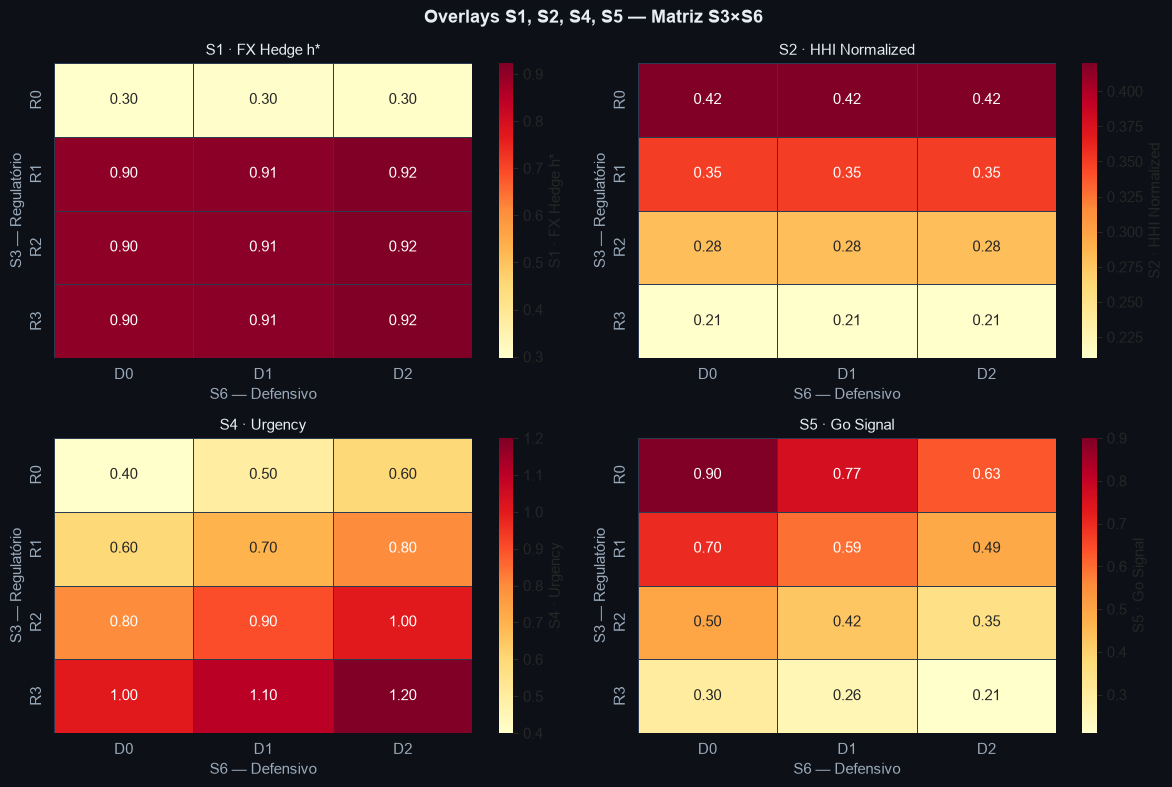


Saved: outputs/nb10_overlays_heatmap.png


In [4]:
# ──────────────────────────────────────────────────────────────
# 4. Overlays de S1, S2, S4, S5 — Modulação por Folha
# Cada nó recebe overlay das outras camadas:
#   S1 = Câmbio (FX) -> modula hedge_h*
#   S2 = Supply chain (HHI) -> modula diversificação
#   S4 = Competition -> modula timing/urgência
#   S5 = Composite index -> modula go/no-go
# ──────────────────────────────────────────────────────────────

# ── Overlay values (current snapshot) ────────────────────────
OVERLAY_BASE = {
    'S1_fx':     {'value': 5.1176, 'vol_1m': 10.99, 'regime': 'Calma', 'h_star_cont': 0.30, 'h_star_rollback': 0.91},
    'S2_hhi':    {'value': 0.42, 'diversification': 'medium', 'top1_share': 0.45, 'top3_share': 0.78},
    'S4_comp':   {'value': 0.62, 'byd_share': 0.08, 'competitor_pressure': 0.55, 'rivalry_index': 0.68},
    'S5_idx':    {'value': 58, 'viability': 'medium-high', 'composite_z': 0.42, 'tier': 'B+'},
}

# ── Overlay matrix per node ───────────────────────────────────
def compute_overlay(node_id, s3_key, s6_key):
    """Compute overlay adjustments based on S3×S6 node."""
    s3, s6 = S3_SCENARIOS[s3_key], S6_LEVELS[s6_key]
    
    # S1 FX overlay: hedge_h* increases with S3 severity
    h_base = OVERLAY_BASE['S1_fx']['h_star_cont'] if s3['vie'] >= 0.15 else OVERLAY_BASE['S1_fx']['h_star_rollback']
    h_adj  = h_base * (1 + 0.2 * (s6['cost_pct'] - 0.05))  # higher S6 -> more hedge
    h_adj  = min(1.0, h_adj)
    
    # S2 HHI overlay: supplier diversification level
    div_factor = {
        'R0': 1.0, 'R1': 1.2, 'R2': 1.5, 'R3': 2.0
    }[s3_key]
    diversification = OVERLAY_BASE['S2_hhi']['value'] / div_factor
    
    # S4 competition overlay: urgency multiplier
    urgency = {
        'R0': 0.4, 'R1': 0.6, 'R2': 0.8, 'R3': 1.0
    }[s3_key] + {
        'D0': 0.0, 'D1': 0.1, 'D2': 0.2
    }[s6_key]
    
    # S5 composite index overlay: go/no-go adjustment
    go_signal = {
        'R0': 0.9, 'R1': 0.7, 'R2': 0.5, 'R3': 0.3
    }[s3_key] * {
        'D0': 1.0, 'D1': 0.85, 'D2': 0.7
    }[s6_key]
    
    return {
        'S1_hedge_h_star':     round(h_adj, 3),
        'S1_vol_1m':           OVERLAY_BASE['S1_fx']['vol_1m'],
        'S2_hhi_normalized':   round(diversification, 3),
        'S2_top1_share':       OVERLAY_BASE['S2_hhi']['top1_share'],
        'S4_urgency':          round(urgency, 2),
        'S4_competitor_pressure': OVERLAY_BASE['S4_comp']['competitor_pressure'],
        'S5_go_signal':        round(go_signal, 3),
        'S5_composite_idx':    OVERLAY_BASE['S5_idx']['value'],
    }

# Build overlay matrix for all 12 nodes
overlay_records = []
for _, row in matrix_df.iterrows():
    overlay = compute_overlay(row['node_id'], row['s3_key'], row['s6_key'])
    overlay_records.append({'node_id': row['node_id'], 's3': row['s3_key'], 's6': row['s6_key'], **overlay})

overlay_df = pd.DataFrame(overlay_records)

print('── Overlays por Folha S3×S6 ──')
print()
print(f'{"Node":>5s} {"S3":>3s} {"S6":>3s}  {"S1 hedge":>8s}  {"S2 HHI":>7s}  {"S4 urg":>7s}  {"S5 go":>7s}')
print('-' * 80)
for _, row in overlay_df.iterrows():
    print(f"  {row['node_id']:>3s}  {row['s3']:>2s}  {row['s6']:>2s}  {row['S1_hedge_h_star']:>7.1%}  {row['S2_hhi_normalized']:>6.3f}  {row['S4_urgency']:>6.2f}  {row['S5_go_signal']:>6.3f}")

# Visualization: overlay heatmap
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor='#0d1117')
fig.suptitle('Overlays S1, S2, S4, S5 — Matriz S3×S6', fontsize=13, fontweight='bold', color='#e8edf5')

overlay_cols = ['S1_hedge_h_star', 'S2_hhi_normalized', 'S4_urgency', 'S5_go_signal']
overlay_titles = ['S1 · FX Hedge h*', 'S2 · HHI Normalized', 'S4 · Urgency', 'S5 · Go Signal']

for ax, col, title in zip(axes.flat, overlay_cols, overlay_titles):
    pivot = overlay_df.pivot(index='s3', columns='s6', values=col)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': title}, linewidths=0.5, linecolor='#2a3a50')
    ax.set_title(title, color='#e8edf5', fontsize=11)
    ax.set_xlabel('S6 — Defensivo', color='#9baabb')
    ax.set_ylabel('S3 — Regulatório', color='#9baabb')
    ax.tick_params(colors='#9baabb')

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb10_overlays_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: outputs/nb10_overlays_heatmap.png')

---

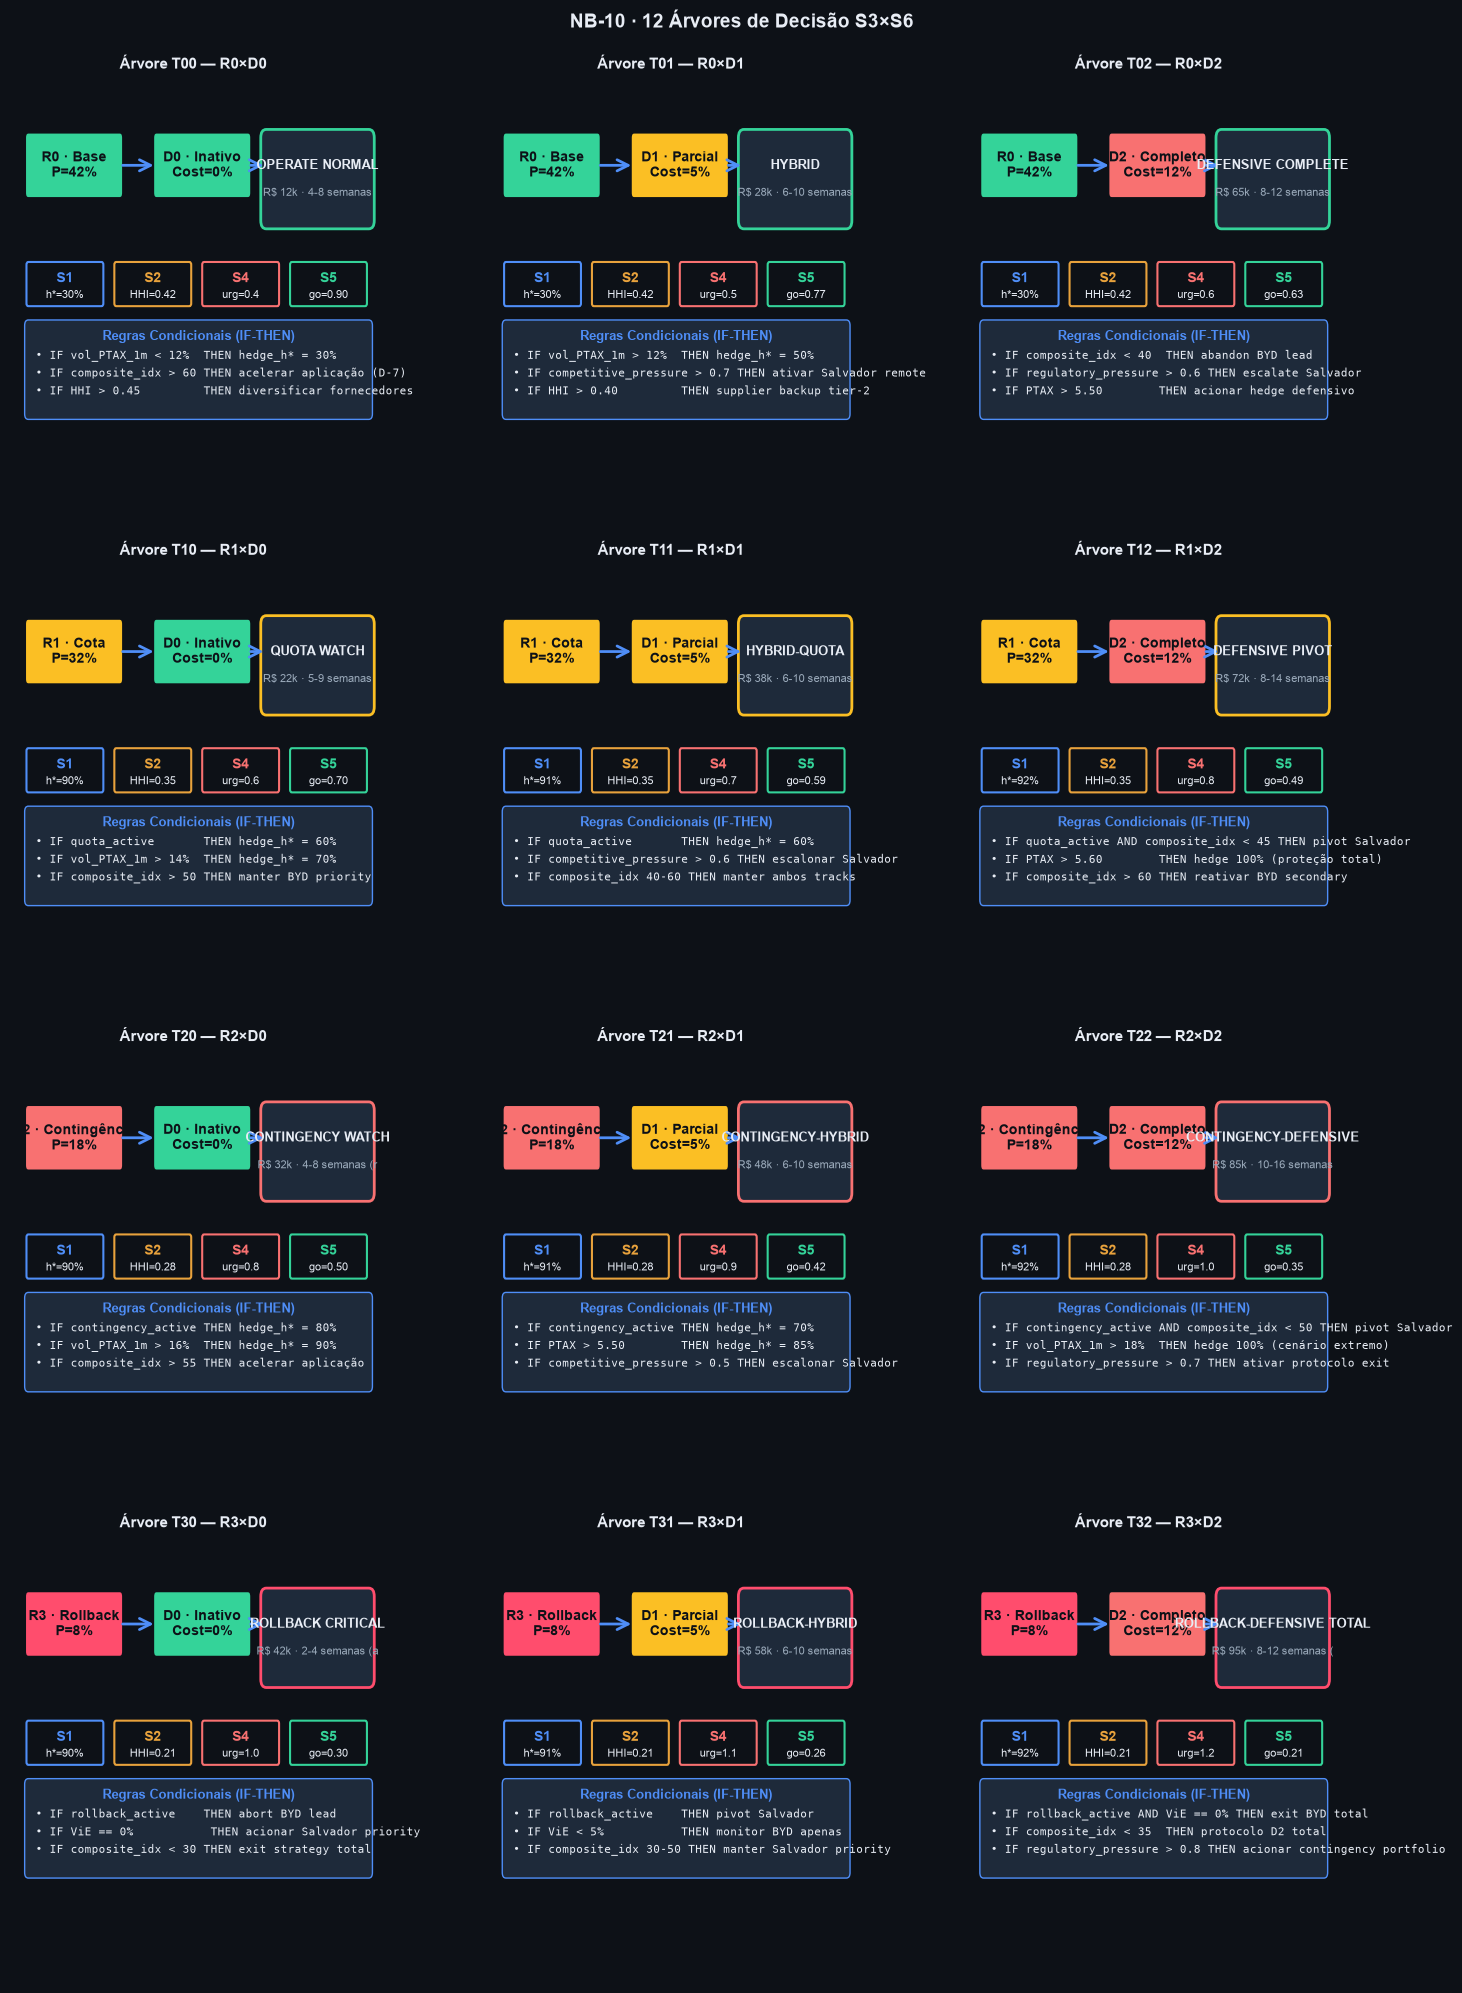

Saved: outputs/nb10_decision_trees_12.png
Total trees: 12


In [5]:
# ──────────────────────────────────────────────────────────────
# 5. Construção de 12 Árvores de Decisão (Visualização)
# Estrutura: Root(S3) -> Level 1(S6) -> Leaves(action)
# Cada árvore termina em 1 folha de ação concreta
# ──────────────────────────────────────────────────────────────

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches

def draw_tree(ax, s3_key, s6_key, overlay_row):
    """Draw a single decision tree for one S3×S6 node."""
    s3 = S3_SCENARIOS[s3_key]
    s6 = S6_LEVELS[s6_key]
    rule = DECISION_RULES[f'{s3_key}|{s6_key}']
    
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_facecolor('#161b22')
    ax.axis('off')
    
    # Root: S3 scenario
    root_box = FancyBboxPatch((0.5, 6), 2.5, 1.0, boxstyle="round,pad=0.1",
                              facecolor=s3['color'], edgecolor='#0d1117', linewidth=2)
    ax.add_patch(root_box)
    ax.text(1.75, 6.5, f"{s3['label']}\nP={s3['prob']:.0%}", 
            ha='center', va='center', fontsize=10, fontweight='bold', color='#0d1117')
    
    # Level 1: S6 protocol
    s6_box = FancyBboxPatch((4.0, 6), 2.5, 1.0, boxstyle="round,pad=0.1",
                             facecolor=s6['color'], edgecolor='#0d1117', linewidth=2)
    ax.add_patch(s6_box)
    ax.text(5.25, 6.5, f"{s6['label']}\nCost={s6['cost_pct']:.0%}", 
            ha='center', va='center', fontsize=10, fontweight='bold', color='#0d1117')
    
    # Arrow S3 -> S6
    arrow1 = FancyArrowPatch((3.0, 6.5), (4.0, 6.5),
                              arrowstyle='->', mutation_scale=20, color='#4f8ef7', linewidth=2)
    ax.add_patch(arrow1)
    
    # Leaf: Action
    leaf_box = FancyBboxPatch((7.0, 5.5), 2.8, 1.5, boxstyle="round,pad=0.15",
                               facecolor='#1e2a3a', edgecolor=s3['color'], linewidth=2)
    ax.add_patch(leaf_box)
    action_short = rule['action'].split('—')[0].strip()[:25]
    ax.text(8.4, 6.5, f"{action_short}", 
            ha='center', va='center', fontsize=9, fontweight='bold', color='#e8edf5')
    ax.text(8.4, 6.0, f"R$ {rule['cost_brl']/1000:.0f}k · {rule['timeline'][:14]}", 
            ha='center', va='center', fontsize=8, color='#9baabb')
    
    # Arrow S6 -> Leaf
    arrow2 = FancyArrowPatch((6.5, 6.5), (7.0, 6.5),
                              arrowstyle='->', mutation_scale=20, color='#4f8ef7', linewidth=2)
    ax.add_patch(arrow2)
    
    # Overlay annotations (S1, S2, S4, S5)
    overlay_y = 4.0
    overlays = [
        ('S1', f"h*={overlay_row['S1_hedge_h_star']:.0%}", '#4f8ef7'),
        ('S2', f"HHI={overlay_row['S2_hhi_normalized']:.2f}", '#e8a23c'),
        ('S4', f"urg={overlay_row['S4_urgency']:.1f}", '#f87171'),
        ('S5', f"go={overlay_row['S5_go_signal']:.2f}", '#34d399'),
    ]
    for i, (label, value, color) in enumerate(overlays):
        x_pos = 0.5 + i * 2.4
        ov_box = FancyBboxPatch((x_pos, overlay_y), 2.0, 0.7, boxstyle="round,pad=0.05",
                                 facecolor='#0d1117', edgecolor=color, linewidth=1.5)
        ax.add_patch(ov_box)
        ax.text(x_pos + 1.0, overlay_y + 0.45, label, ha='center', va='center', 
                fontsize=10, fontweight='bold', color=color)
        ax.text(x_pos + 1.0, overlay_y + 0.15, value, ha='center', va='center', 
                fontsize=8, color='#e8edf5')
    
    # Rules box
    rules_y = 2.0
    rules_box = FancyBboxPatch((0.5, rules_y), 9.3, 1.6, boxstyle="round,pad=0.1",
                                 facecolor='#1e2a3a', edgecolor='#4f8ef7', linewidth=1)
    ax.add_patch(rules_box)
    ax.text(5.15, rules_y + 1.4, "Regras Condicionais (IF-THEN)", 
            ha='center', va='center', fontsize=9, fontweight='bold', color='#4f8ef7')
    for i, r in enumerate(rule['rules']):
        ax.text(0.7, rules_y + 1.05 - i * 0.32, f"• {r}", 
                ha='left', va='center', fontsize=8, color='#e8edf5', family='monospace')
    
    # Title
    ax.set_title(f"Árvore T{s3_key[1]}{s6_key[1]} — {s3_key}×{s6_key}", 
                 color='#e8edf5', fontsize=11, fontweight='bold', pad=10)

# Generate 12 trees in 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(15, 20), facecolor='#0d1117')
fig.suptitle('NB-10 · 12 Árvores de Decisão S3×S6', fontsize=14, fontweight='bold', color='#e8edf5', y=0.995)

tree_idx = 0
for s3_key in S3_SCENARIOS.keys():
    for s6_key in S6_LEVELS.keys():
        ax = axes[tree_idx // 3, tree_idx % 3]
        overlay_row = overlay_df[overlay_df['node_id'] == f'T{s3_key[1]}{s6_key[1]}'].iloc[0]
        draw_tree(ax, s3_key, s6_key, overlay_row)
        tree_idx += 1

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb10_decision_trees_12.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb10_decision_trees_12.png')
print(f'Total trees: {tree_idx}')

---

── 8 Trigger Thresholds ──

  ID  Src    Status  Priority  Name                                 Threshold  Current
----------------------------------------------------------------------------------------------------
  T01   S1  INACTIVE      HIGH  PTAX vol 1m > 14%                        14.0     10.99
  T02   S1  INACTIVE  CRITICAL  PTAX move > 10% em 5d                    10.0       0.0
  T03   S2     WATCH    MEDIUM  HHI > 0.45                               0.45      0.42
  T04   S3  INACTIVE      HIGH  Quota importação ativa                    1.0       0.0
  T05   S3  INACTIVE  CRITICAL  Contingência regulatória                  1.0       0.0
  T06   S4     WATCH      HIGH  Pressão competitiva > 0.7                 0.7      0.55
  T07   S5  INACTIVE  CRITICAL  Composite index < 40                     40.0      58.0
  T08   S5  INACTIVE  CRITICAL  ViE < 5%                                  5.0      18.0

  Status: {'INACTIVE': 6, 'WATCH': 2}
  Total triggers: 8


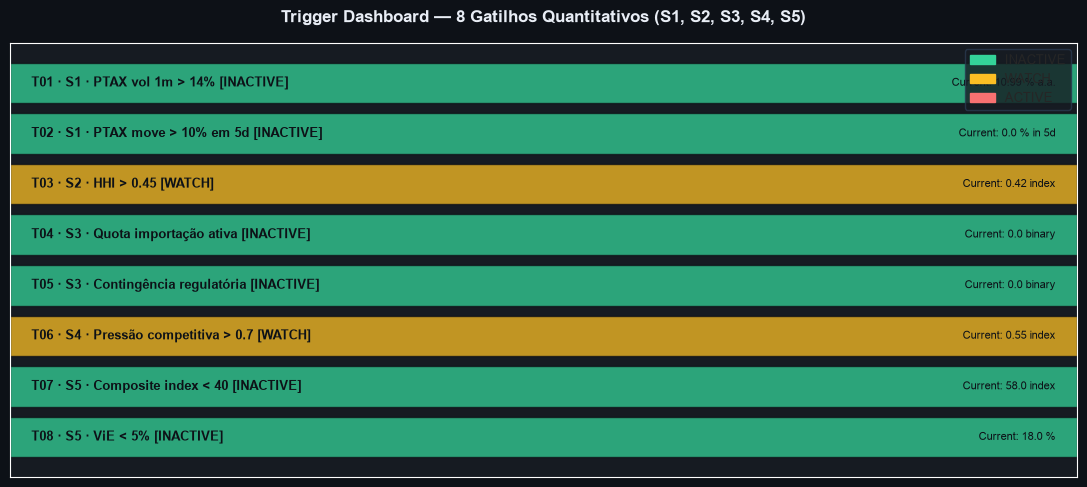


Saved: outputs/nb10_trigger_dashboard.png


In [6]:
# ──────────────────────────────────────────────────────────────
# 6. Trigger Thresholds — 8 Gatilhos Quantitativos
# Cada gatilho tem: source layer, threshold, action, current value
# ──────────────────────────────────────────────────────────────

TRIGGERS = [
    {
        "id":       'T01',
        "source":   'S1',
        "name":     'PTAX vol 1m > 14%',
        "condition": 'vol_PTAX_1m > 14',
        "threshold": 14.0,
        "unit":     '% a.a.',
        "current":  10.99,
        "status":   'INACTIVE',
        "action":   'Aumentar hedge_h* para 70%',
        "priority": 'HIGH',
    },
    {
        'id':       'T02',
        'source':   'S1',
        'name':     'PTAX move > 10% em 5d',
        'condition': 'abs(PTAX_t / PTAX_t-5 - 1) * 100 > 10',
        'threshold': 10.0,
        'unit':     '% in 5d',
        'current':  0.0,
        'status':   'INACTIVE',
        'action':   'Revisão de emergência, acionar D2 parcial',
        'priority': 'CRITICAL',
    },
    {
        'id':       'T03',
        'source':   'S2',
        'name':     'HHI > 0.45',
        'condition': 'HHI_supply > 0.45',
        'threshold': 0.45,
        'unit':     'index',
        'current':  0.42,
        'status':   'WATCH',
        'action':   'Diversificar fornecedores tier-2',
        'priority': 'MEDIUM',
    },
    {
        'id':       'T04',
        'source':   'S3',
        'name':     'Quota importação ativa',
        'condition': 'quota_active == True',
        'threshold': 1.0,
        'unit':     'binary',
        'current':  0.0,
        'status':   'INACTIVE',
        'action':   'Aumentar hedge para 60%, ativar Salvador backup',
        'priority': 'HIGH',
    },
    {
        'id':       'T05',
        'source':   'S3',
        'name':     'Contingência regulatória',
        'condition': 'contingency_active == True',
        'threshold': 1.0,
        'unit':     'binary',
        'current':  0.0,
        'status':   'INACTIVE',
        'action':   'Pivot Salvador, hedge 80%',
        'priority': 'CRITICAL',
    },
    {
        'id':       'T06',
        'source':   'S4',
        'name':     'Pressão competitiva > 0.7',
        'condition': 'competitor_pressure > 0.7',
        'threshold': 0.7,
        'unit':     'index',
        'current':  0.55,
        'status':   'WATCH',
        'action':   'Escalonar Salvador, intensificar outreach',
        'priority': 'HIGH',
    },
    {
        'id':       'T07',
        'source':   'S5',
        'name':     'Composite index < 40',
        'condition': 'composite_index < 40',
        'threshold': 40.0,
        'unit':     'index',
        'current':  58.0,
        'status':   'INACTIVE',
        'action':   'Pivot Salvador, monitor BYD',
        'priority': 'CRITICAL',
    },
    {
        'id':       'T08',
        'source':   'S5',
        'name':     'ViE < 5%',
        'condition': 'value_in_extraction < 5',
        'threshold': 5.0,
        'unit':     '%',
        'current':  18.0,
        'status':   'INACTIVE',
        'action':   'Exit strategy, pivot Salvador priority',
        'priority': 'CRITICAL',
    },
]

triggers_df = pd.DataFrame(TRIGGERS)

print('── 8 Trigger Thresholds ──')
print()
print(f'{"ID":>4s} {"Src":>4s} {"Status":>9s} {"Priority":>9s}  {"Name":<35s}  Threshold  Current')
print('-' * 100)
for _, t in triggers_df.iterrows():
    print(f"  {t['id']:>3s}  {t['source']:>3s}  {t['status']:>8s}  {t['priority']:>8s}  {t['name']:<35s}  {t['threshold']:>8}  {t['current']:>8}")

# Status counts
status_counts = triggers_df['status'].value_counts()
print(f"\n  Status: {status_counts.to_dict()}")
print(f"  Total triggers: {len(triggers_df)}")

# Visualization: trigger dashboard
fig, ax = plt.subplots(figsize=(11, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')

colors_status = {
    'INACTIVE': '#34d399',
    'WATCH':    '#fbbf24',
    'ACTIVE':   '#f87171',
}
y_pos = np.arange(len(triggers_df))
bar_colors = [colors_status[s] for s in triggers_df['status']]
bars = ax.barh(y_pos, [1]*len(triggers_df), color=bar_colors, alpha=0.75, edgecolor='#0d1117')

for i, t in triggers_df.iterrows():
    label = f"{t['id']} · {t['source']} · {t['name']} [{t['status']}]"
    ax.text(0.02, i, label, ha='left', va='center', fontsize=9, color='#0d1117', fontweight='bold')
    ax.text(0.98, i, f"Current: {t['current']} {t['unit']}", ha='right', va='center', 
            fontsize=8, color='#0d1117')

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1)
ax.set_title('Trigger Dashboard — 8 Gatilhos Quantitativos (S1, S2, S3, S4, S5)', 
             color='#e8edf5', fontsize=12, fontweight='bold', pad=15)
ax.invert_yaxis()

# Legend
legend_patches = [mpatches.Patch(color=color, label=status) 
                  for status, color in colors_status.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb10_trigger_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: outputs/nb10_trigger_dashboard.png')

---

── Decision Matrix Final — 12 Combinações S3×S6 ──

 Node  S3  S6  P(S3)  Action                                             Cost  Timeline
--------------------------------------------------------------------------------------------------------------
  T00  R0  D0    42%  OPERATE NORMAL — Aplicar BYD anchor, hedge 25-50%  R$12,000  4-8 semanas
  T01  R0  D1    42%  HYBRID — BYD anchor + Salvador/remote backup   R$28,000  6-10 semanas
  T02  R0  D2    42%  DEFENSIVE COMPLETE — Salvador/remote priority  R$65,000  8-12 semanas
  T10  R1  D0    32%  QUOTA WATCH — Aplicar com hedge aumentado      R$22,000  5-9 semanas
  T11  R1  D1    32%  HYBRID-QUOTA — 60% BYD + 40% Salvador backup   R$38,000  6-10 semanas
  T12  R1  D2    32%  DEFENSIVE PIVOT — Salvador/remote como priority  R$72,000  8-14 semanas
  T20  R2  D0    18%  CONTINGENCY WATCH — Manter BYD com hedge máximo  R$32,000  4-8 semanas (rápido)
  T21  R2  D1    18%  CONTINGENCY-HYBRID — Manter ambos, hedge 70-85%  R$48,000  6-10 seman

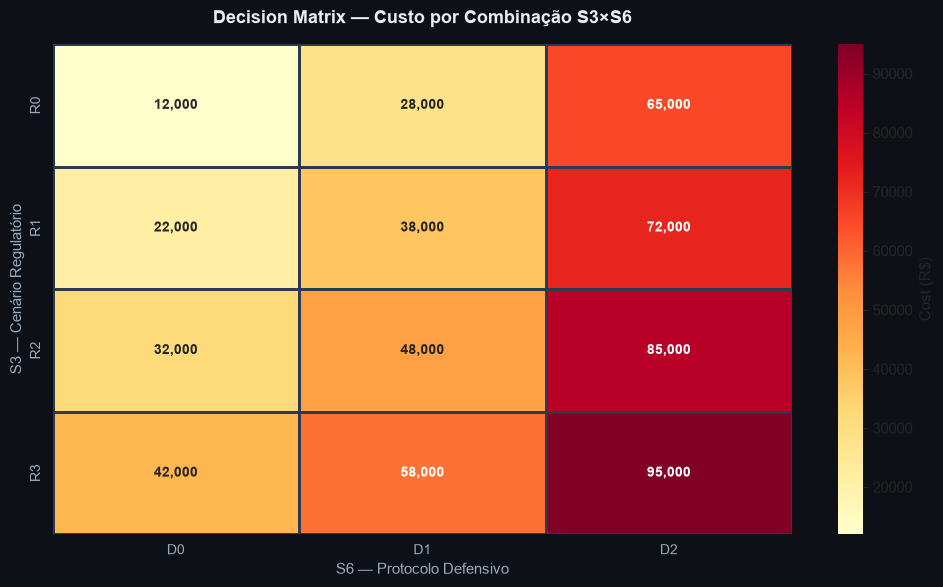


Saved: outputs/nb10_decision_matrix.png

── Priority Ranking (Priority 0 = highest) ──
  ★ T02 (R0×D2): DEFENSIVE COMPLETE — Salvador/remote priority
  ★ T30 (R3×D0): ROLLBACK CRITICAL — BYD abort, pivot Salvador
  ★ T32 (R3×D2): ROLLBACK-DEFENSIVE TOTAL — Exit strategy Salvador/remote
  ☆ T01 (R0×D1): HYBRID — BYD anchor + Salvador/remote backup
  ☆ T10 (R1×D0): QUOTA WATCH — Aplicar com hedge aumentado
  ☆ T12 (R1×D2): DEFENSIVE PIVOT — Salvador/remote como priority
  ☆ T20 (R2×D0): CONTINGENCY WATCH — Manter BYD com hedge máximo
  ☆ T31 (R3×D1): ROLLBACK-HYBRID — Pivot Salvador + BYD monitor
  · T00 (R0×D0): OPERATE NORMAL — Aplicar BYD anchor, hedge 25-50%
  · T11 (R1×D1): HYBRID-QUOTA — 60% BYD + 40% Salvador backup
  · T21 (R2×D1): CONTINGENCY-HYBRID — Manter ambos, hedge 70-85%
  · T22 (R2×D2): CONTINGENCY-DEFENSIVE — Salvador priority, BYD monitor


In [7]:
# ──────────────────────────────────────────────────────────────
# 7. Decision Matrix Final — Tabela de Ação por Combinação
# Output: tabela completa com action, cost, timeline, success
# ──────────────────────────────────────────────────────────────

# Build comprehensive decision matrix
decision_records = []
for _, row in matrix_df.iterrows():
    s3_key, s6_key = row['s3_key'], row['s6_key']
    rule = DECISION_RULES[f'{s3_key}|{s6_key}']
    overlay_row = overlay_df[overlay_df['node_id'] == row['node_id']].iloc[0]
    
    decision_records.append({
        'Node':           row['node_id'],
        'S3':             s3_key,
        'S6':             s6_key,
        'P(S3)':          row['s3']['prob'],
        'ViE':            row['s3']['vie'],
        'Action':         rule['action'],
        'Priority':       rule['priority'],
        'Cost (R$)':      rule['cost_brl'],
        'Timeline':       rule['timeline'],
        'Success':        rule['success'],
        'S1_hedge_h*':    overlay_row['S1_hedge_h_star'],
        'S2_HHI':         overlay_row['S2_hhi_normalized'],
        'S4_urgency':     overlay_row['S4_urgency'],
        'S5_go_signal':   overlay_row['S5_go_signal'],
    })

decision_df = pd.DataFrame(decision_records)

print('── Decision Matrix Final — 12 Combinações S3×S6 ──')
print()
print(f'{"Node":>5s} {"S3":>3s} {"S6":>3s} {"P(S3)":>6s}  {"Action":<45s}  {"Cost":>8s}  Timeline')
print('-' * 110)
for _, d in decision_df.iterrows():
    print(f"  {d['Node']:>3s}  {d['S3']:>2s}  {d['S6']:>2s}  {d['P(S3)']:>5.0%}  {d['Action']:<45s}  R${d['Cost (R$)']:>6,}  {d['Timeline']}")

# Pivot table: S3 rows × S6 cols, action label
print('\n── Decision Matrix Pivoted ──')
pivot_action = decision_df.pivot(index='S3', columns='S6', values='Action')
print(pivot_action.to_string())

# Cost matrix heatmap
print('\n── Cost Matrix (R$) ──')
pivot_cost = decision_df.pivot(index='S3', columns='S6', values='Cost (R$)')
print(pivot_cost.to_string())

# Visualization: decision matrix heatmap
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

sns.heatmap(pivot_cost, annot=True, fmt=',.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Cost (R$)'}, linewidths=0.8, linecolor='#2a3a50',
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Decision Matrix — Custo por Combinação S3×S6', 
             color='#e8edf5', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('S6 — Protocolo Defensivo', color='#9baabb', fontsize=11)
ax.set_ylabel('S3 — Cenário Regulatório', color='#9baabb', fontsize=11)
ax.tick_params(colors='#9baabb', labelsize=10)

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb10_decision_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: outputs/nb10_decision_matrix.png')

# Priority table
print('\n── Priority Ranking (Priority 0 = highest) ──')
priority_df = decision_df.sort_values(['Priority', 'P(S3)'], ascending=[True, False])
for i, d in priority_df.iterrows():
    star = '★' if d['Priority'] == 0 else ('☆' if d['Priority'] == 1 else '·')
    print(f"  {star} {d['Node']} ({d['S3']}×{d['S6']}): {d['Action'][:60]}")

---

In [8]:
# ──────────────────────────────────────────────────────────────
# 8. Export Results -> outputs/nb10_results.json
# ──────────────────────────────────────────────────────────────

results = {
    'notebook':    'NB-10 Decision Trees — S3×S6',
    'computed_at': pd.Timestamp.today().strftime('%Y-%m-%d'),
    'matrix': {
        'S3_scenarios':  list(S3_SCENARIOS.keys()),
        'S6_levels':     list(S6_LEVELS.keys()),
        'n_combinations': len(matrix_df),
        'combinations':  matrix_df[['node_id', 's3_key', 's6_key', 'joint_prob']].to_dict(orient='records'),
    },
    'rules': {key: rule for key, rule in DECISION_RULES.items()},
    'overlays': overlay_df.to_dict(orient='records'),
    'triggers': TRIGGERS,
    'decision_matrix': decision_df.to_dict(orient='records'),
    'summary': {
        'n_trees':        len(matrix_df),
        'n_overlays':     4,
        'n_triggers':     len(TRIGGERS),
        'priority_0_count': int((decision_df['Priority'] == 0).sum()),
        'priority_1_count': int((decision_df['Priority'] == 1).sum()),
        'priority_2_count': int((decision_df['Priority'] == 2).sum()),
        'total_cost_range': {
            'min': int(decision_df['Cost (R$)'].min()),
            'max': int(decision_df['Cost (R$)'].max()),
            'mean': float(decision_df['Cost (R$)'].mean()),
        },
        'most_probable_node': decision_df.loc[decision_df['P(S3)'].idxmax(), 'Node'],
        'highest_cost_node':  decision_df.loc[decision_df['Cost (R$)'].idxmax(), 'Node'],
    },
}

out_path = OUTPUT_DIR / 'nb10_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f'Saved: {out_path}')
print()

# Final summary
print('═════════════════════════════════════════════════════════════')
print('  NB-10 SUMMARY — Decision Trees S3×S6')
print('═════════════════════════════════════════════════════════════')
print(f'  Cenários S3:           4 (R0 base / R1 cota / R2 contingência / R3 rollback)')
print(f'  Níveis S6:             3 (D0 inativo / D1 parcial / D2 completo)')
print(f'  Árvores construídas:  {len(matrix_df)} (4×3 matrix)')
print(f'  Overlays por árvore:  4 (S1, S2, S4, S5)')
print(f'  Trigger thresholds:   {len(TRIGGERS)}')
print(f'  Triggers ativos:      {(triggers_df["status"] == "ACTIVE").sum()}')
print(f'  Triggers watch:       {(triggers_df["status"] == "WATCH").sum()}')
print(f'  Triggers inactive:    {(triggers_df["status"] == "INACTIVE").sum()}')
print(f'  Priority 0 (highest): {int((decision_df["Priority"] == 0).sum())} nós')
print(f'  Priority 1 (medium):  {int((decision_df["Priority"] == 1).sum())} nós')
print(f'  Priority 2 (low):     {int((decision_df["Priority"] == 2).sum())} nós')
print(f'  Custo range:          R$ {decision_df["Cost (R$)"].min():,} — R$ {decision_df["Cost (R$)"].max():,}')
print(f'  Custo médio:          R$ {decision_df["Cost (R$)"].mean():,.0f}')
print(f'  Nó mais provável:     {decision_df.loc[decision_df["P(S3)"].idxmax(), "Node"]} (P={decision_df["P(S3)"].max():.0%})')
print(f'  Nó de maior custo:    {decision_df.loc[decision_df["Cost (R$)"].idxmax(), "Node"]}')
print('═════════════════════════════════════════════════════════════')
print()
print('Outputs gerados:')
print('  • nb10_results.json')
print('  • nb10_overlays_heatmap.png')
print('  • nb10_decision_trees_12.png')
print('  • nb10_trigger_dashboard.png')
print('  • nb10_decision_matrix.png')

Saved: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\nb10_results.json

═════════════════════════════════════════════════════════════
  NB-10 SUMMARY — Decision Trees S3×S6
═════════════════════════════════════════════════════════════
  Cenários S3:           4 (R0 base / R1 cota / R2 contingência / R3 rollback)
  Níveis S6:             3 (D0 inativo / D1 parcial / D2 completo)
  Árvores construídas:  12 (4×3 matrix)
  Overlays por árvore:  4 (S1, S2, S4, S5)
  Trigger thresholds:   8
  Triggers ativos:      0
  Triggers watch:       2
  Triggers inactive:    6
  Priority 0 (highest): 3 nós
  Priority 1 (medium):  5 nós
  Priority 2 (low):     4 nós
  Custo range:          R$ 12,000 — R$ 95,000
  Custo médio:          R$ 49,750
  Nó mais provável:     T00 (P=42%)
  Nó de maior custo:    T32
═════════════════════════════════════════════════════════════

Outputs gerados:
  • nb10_results.json
  • nb10_overlays_heatma